In [1]:
############ IMPORT LIBRARIES ############

from QNBAnalytics_ML import data
from QNBAnalytics_ML import skills_api
from QNBAnalytics_ML.feature_importances import plot_feature_importances
from QNBAnalytics_ML.param_grid_best import grids as param_grid_best
import pandas as pd
import numpy as np
import pickle
import datetime
import os
import time

version = "training"
start_time = datetime.datetime.now()

In [4]:
data = pd.read_csv('Data/data.csv', low_memory=False)


In [ ]:
pd.DataFrame(data.isna().sum()).to_csv('missing_values.csv')

In [ ]:
missing = pd.DataFrame(data.isna().sum())
missing.to_csv('missing_values.csv')

In [2]:
############ ENTER PARAMETERS ############

index_col = "MUQAVILE"  # index column
target_col = "TARGET"  # target column


## (OPTIONAL)

cols_to_drop = [
    "CC_O_4M6MWPS_EVER","ALL_O_4M6MWPS_EVER_O","ALL_O_7M12MWPS_EVER","ALL_O_7M12MWPS_EVER_O","ALL_OSMLMT_CWPS1_6_EVER",
    "CC_O_13M24MWPS_EVER","CC_O_13M24MWPS_EVER_O","CC_O_7M12MWPS_EVER","CC_O_7M12MWPS_EVER_O","CCOL_O_4M6MWPS_EVER",
    "CL_O_13M24MWPS_EVER_O","HL_EVERWPS_EVER","HL_O_13M24MWPS_365DP","HL_O_3MWPS_365DP","HL_O_4M6MWPS_EVER_O",
    "HL_O_7M12MWPS_EVER_O","HL_O_EVERWPS_365DP","OL_O_3MWPS_183D365D","OL_O_3MWPS_365DP","OL_O_4M6MWPS_183D365D",
    "OL_O_4M6MWPS_91D182D","OL_O_7M12MWPS_365DP","OL_O_EVERWPS_183D365D","OL_O_EVERWPS_365DP","OL_O_EVERWPS_90D",
    "OL_O_EVERWPS_91D182D","OL_OLMTUTL_CWPS0_90D_O","BGN",
############ columns that should not be used for training ############
    "ID", "FIN", "MKR_ID", "MKR_DATE", "IDS", "SCR_CONSTANT", "SCR_MULTIPLIER",
############ REMOVE ALL WORK-RELATED FEATURES FOR BASELINE TEST ############
    # MAAS	ISH_YERI	VEZIFE	VEZIFELER	WORKGROUP	QRUP	SAHƏLƏR	SEKTOR	PARTNYORLUQ

    "QRUP",           # Organization type (Public/Private/Other)
    "MAAS",           # Salary amount
    "WORKGROUP",      # Employment type (main staff, management, etc.)
    "SEKTOR",         # Business sector (Oil-gas, Banks, Schools, etc.)
    "PARTNYORLUQ",    # Partnership
    "ISH_YERI",       # Workplace
    "VEZIFE",         # Position/role
    "VEZIFELER",      # Positions (plural)
    "SAHƏLƏR",         # Work locations
]


In [ ]:
############ TEMPORAL SPLIT CONFIGURATION ############
# 
# CRITICAL FIX: Use proper temporal split for credit scoring
# - Train: Earlier time period (model learns from past)
# - Test: Later time period (model predicts future)
# 
# This ensures realistic performance estimates and prevents distribution shift

USE_TEMPORAL_SPLIT = True  # Set to False to use old random split (not recommended!)

if USE_TEMPORAL_SPLIT:
    print("=" * 70)
    print("USING TEMPORAL TRAIN/TEST SPLIT")
    print("=" * 70)
    print("Train: 2018-01-01 to 2020-06-30 (historical data)")
    print("Test:  2020-07-01 to 2021-10-30 (future data)")
    print("This simulates real-world deployment: predict future from past")
    print("=" * 70)
else:
    print("WARNING: Using old random split - not recommended for production!")
    print("Expected: Train/Test distribution mismatch and overfitting")

USING TEMPORAL TRAIN/TEST SPLIT
Train: 2018-01-01 to 2020-06-30 (historical data)
Test:  2020-07-01 to 2021-10-30 (future data)
This simulates real-world deployment: predict future from past


In [4]:
############ READ DATA FROM SINGLE CSV ############

print('=' * 70)
print('LOADING DATA FROM Data/data.csv')
print('=' * 70)

print('\n[1/3] Loading data...')
data = pd.read_csv('Data/data.csv', low_memory=False)
print(f'[OK] Data loaded: {data.shape}')

if 'MKR_DATE' in data.columns:
    data['MKR_DATE_dt'] = pd.to_datetime(data['MKR_DATE'])
    split_date = pd.to_datetime('2020-06-30')
    data_train = data[data['MKR_DATE_dt'] <= split_date].copy()
    data_test = data[data['MKR_DATE_dt'] > split_date].copy()
    data_train = data_train.drop(columns=['MKR_DATE_dt'])
    data_test = data_test.drop(columns=['MKR_DATE_dt'])
    print(f'[OK] Temporal split at {split_date.date()}')
else:
    split_idx = int(len(data) * 0.6)
    data_train = data.iloc[:split_idx].copy()
    data_test = data.iloc[split_idx:].copy()
    print(f'[OK] Sequential split at row {split_idx}')

print(f'[OK] Train: {data_train.shape}, Test: {data_test.shape}')

print('\n[3/4] Processing train data...')
missing_target_train = data_train[target_col].isna().sum()
if missing_target_train > 0:
    print(f'Removing {missing_target_train} rows with missing TARGET from train')
    data_train = data_train[data_train[target_col].notna()].copy()

train = data_train.set_index(index_col).rename(columns={target_col: 'TARGET'})
y_train = train['TARGET']

if y_train.isna().any():
    nan_count = y_train.isna().sum()
    print(f'WARNING: Found {nan_count} NaN values in y_train - removing them')
    valid_mask = y_train.notna()
    y_train = y_train[valid_mask]
    train = train[valid_mask]

cols_to_drop_existing = [col for col in cols_to_drop if col in train.columns]
x_train = train.drop(columns=['TARGET']+cols_to_drop_existing, inplace=False)

print(f'[OK] Training features: {x_train.shape}')
print(f'[OK] Training default rate: {y_train.mean():.2%}')
if 'MKR_DATE' in data_train.columns:
    print(f'[OK] Train date range: {pd.to_datetime(data_train["MKR_DATE"]).min()} to {pd.to_datetime(data_train["MKR_DATE"]).max()}')

print('\n[4/4] Processing test data...')
missing_target_test = data_test[target_col].isna().sum()
if missing_target_test > 0:
    print(f'Removing {missing_target_test} rows with missing TARGET from test')
    data_test = data_test[data_test[target_col].notna()].copy()

test = data_test.set_index(index_col).rename(columns={target_col: 'TARGET'})
y_test = test['TARGET']

if y_test.isna().any():
    nan_count = y_test.isna().sum()
    print(f'WARNING: Found {nan_count} NaN values in y_test - removing them')
    valid_mask = y_test.notna()
    y_test = y_test[valid_mask]
    test = test[valid_mask]

cols_to_drop_existing_test = [col for col in cols_to_drop if col in test.columns]
x_test = test.drop(columns=['TARGET']+cols_to_drop_existing_test, inplace=False)

print(f'[OK] Test features: {x_test.shape}')
print(f'[OK] Test default rate: {y_test.mean():.2%}')
if 'MKR_DATE' in data_test.columns:
    print(f'[OK] Test date range: {pd.to_datetime(data_test["MKR_DATE"]).min()} to {pd.to_datetime(data_test["MKR_DATE"]).max()}')

assert not y_train.isna().any(), 'FATAL: y_train still has NaN values!'
assert not y_test.isna().any(), 'FATAL: y_test still has NaN values!'

print('\n' + '=' * 70)
print('DATA LOADED - READY FOR TRAINING')
print('=' * 70)
print(f'VEZIFELER excluded: {"VEZIFELER" in x_train.columns}, MAAS excluded: {"MAAS" in x_train.columns}')

LOADING DATA FROM Data/data.csv

[1/3] Loading data...
[OK] Data loaded: (96327, 2748)
[OK] Temporal split at 2020-06-30
[OK] Train: (49811, 2748), Test: (46516, 2748)

[3/4] Processing train data...
[OK] Training features: (49811, 2705)
[OK] Training default rate: 2.28%
[OK] Train date range: 2018-07-28 00:00:00 to 2020-06-30 00:00:00

[4/4] Processing test data...
[OK] Test features: (46516, 2705)
[OK] Test default rate: 1.34%
[OK] Test date range: 2020-07-01 00:00:00 to 2021-10-30 00:00:00

DATA LOADED - READY FOR TRAINING
VEZIFELER excluded: False, MAAS excluded: False


In [5]:
x_train.columns

Index(['CL_OCNT_EVER', 'CL_OCNT_90D', 'CL_OCNT_182D', 'CL_OCNT_183D365D',
       'CL_OCNT_365D', 'CL_OCNT_91D182D', 'CL_OCNT_91D365D',
       'CL_OCNT_CWPS0_EVER', 'CL_OCNT_CWPS0_90D', 'CL_OCNT_CWPS0_182D',
       ...
       'CL_OAVGINSDIVSMTOB_EVER', 'CL_OAVGINSDIVSMTOB_90D',
       'CL_OAVGINSDIVSMTOB_182D', 'CL_OAVGINSDIVSMTOB_183D365D',
       'CL_OAVGINSDIVSMTOB_365D', 'CL_OSMINSDIVSMTOB_EVER',
       'CL_OSMINSDIVSMTOB_90D', 'CL_OSMINSDIVSMTOB_182D',
       'CL_OSMINSDIVSMTOB_183D365D', 'CL_OSMINSDIVSMTOB_365D'],
      dtype='object', length=2705)

In [6]:
## PIPELINE SETTINGS

apply_data_explore = True
apply_null_elimination = True
apply_constant_elimination = True
apply_null_imputation = True      # BEFORE binning - correct!
apply_binning = True               # PRIMARY encoding method
apply_low_gini_elimination = True  # AFTER binning - correct!
apply_correlated_feature_elimination = True
apply_scaling = False
apply_categorical_encoding = False  # SET TO FALSE - binning handles it!

apply_LR = True

In [7]:
class Pipeline_Base:
    def train(self, x_train, y_train, x_test=[], y_test=[]):
        if (len(x_test) > 0) & (len(y_test) > 0):
            x_val = x_test.copy()
            y_val = y_test.copy()

        self.pipeline = skills_api.ClassifierPipeline(x_train, y_train, x_val, y_val)

        ########################   Data Explore    ############################

        if apply_data_explore:
            self.pipeline.data_explore()


        ########################   Drop Null Features    ############################

        if apply_null_elimination:
            self.pipeline.feature_elimination(eliminator='drop_null_features', params={'threshold': 0.99})


        ########################   Drop Constant Features    ############################

        if apply_constant_elimination:
            self.pipeline.feature_elimination(eliminator='drop_constant_features', params={'missing_values':'ignore'})


        ########################   Null Imputation    ############################

        if apply_null_imputation:
            self.pipeline.null_imputation()


        ########################   Binning (WOE Encoding for ALL features)    ############################
        # THIS IS NOW THE PRIMARY ENCODING METHOD
        # Handles numeric (with binning first) + categorical (directly)

        if apply_binning:
            self.pipeline.binning()


        ########################   Low Gini Elimination    ############################
        # Now all features are WOE-encoded (numeric), so Gini can be calculated

        if apply_low_gini_elimination:
            self.pipeline.feature_elimination(eliminator='drop_low_gini_features', params={'threshold':0.05, 'missing_values':'ignore'})


        ########################   Feature Elimination    ############################

        if apply_correlated_feature_elimination:
            self.pipeline.feature_elimination(eliminator='correlated_lower_gini_feature_elimination', params={'missing_values':'ignore'})


        ########################   Scaling    ############################

        if apply_scaling:
            self.pipeline.scaling()


        #########################      Logistic Regression      #############################

        if apply_LR:
            self.pipeline.LogisticRegression(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['logistic_regression_base'])


    def apply(self, x_test, y_test=[]):
        predicts = self.pipeline.test(test = x_test, y_test=y_test)
        return predicts

2025-11-26 15:00:14,628 - qnbanalytics - INFO - There might be multiple ID in dataframe
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
2025-11-26 15:00:18,747 - qnbanalytics - INFO - Data Type Conversion started
2025-11-26 15:00:18,750 - qnbanalytics - INFO - Data Type Conversion completed
2025-11-26 15:00:20,764 - qnbanalytics - INFO - Feature Elimination Started: drop_null_features
2025-11-26 15:00:27,153 - qnbanalytics - INFO - Feature Elimination completed.
2025-11-26 15:00:30,462 - qnbanalytics - INFO - No ID detected!
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /=

Fitting WOE encoding for 162 variables using category_encoders.WOEEncoder...
Calculating Gini scores for all features...
WOE encoding fitted for 162 variables


2025-11-26 15:00:48,906 - qnbanalytics - INFO - Opt binning completed... 
2025-11-26 15:00:49,367 - qnbanalytics - INFO - No ID detected!
2025-11-26 15:00:49,659 - qnbanalytics - INFO - Data Type Conversion started
2025-11-26 15:00:49,661 - qnbanalytics - INFO - Data Type Conversion completed
2025-11-26 15:00:49,770 - qnbanalytics - INFO - Feature Elimination Started: drop_low_gini_features
2025-11-26 15:00:53,531 - qnbanalytics - INFO - Feature Elimination completed.
2025-11-26 15:00:53,783 - qnbanalytics - INFO - No ID detected!
2025-11-26 15:00:53,896 - qnbanalytics - INFO - Data Type Conversion started
2025-11-26 15:00:53,897 - qnbanalytics - INFO - Data Type Conversion completed
2025-11-26 15:00:53,953 - qnbanalytics - INFO - Feature Elimination Started: correlated_lower_gini_feature_elimination
c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\elimination.py:461: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

Fitting 3 folds for each of 1 candidates, totalling 3 fits


c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
2025-11-26 15:00:57,683 - qnbanalytics - INFO - Refitting to all data...
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier


c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\sklearn\base.py:1206: FutureWarning: passing a class to None is deprecated and will be removed in 1.8. Use an instance of the class instead.
  warnings.warn(


is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier


c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:133: UserWarning: Model is linear, disabling fast option...
  warnings.warn("Model is linear, disabling fast option...") if fast else print("")
c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:138: UserWarning: Your model is LogisticRegression(C=0.03726121757536122, multi_class='auto', random_state=48)
  warnings.warn(f"""Your model is {model}""")
c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:139: UserWarning: If your model is not TreeBased, Linear or Deep Learning model, make sure to use agnostic option and give model as predict_proba function.
  warnings.warn(f"""If your model is not TreeBased, Linear or Deep Learning model, make sure to use agnostic option and give model as predict_proba function.""")
c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:208: FutureWarning: 

Passing `palette` without assigning `hu

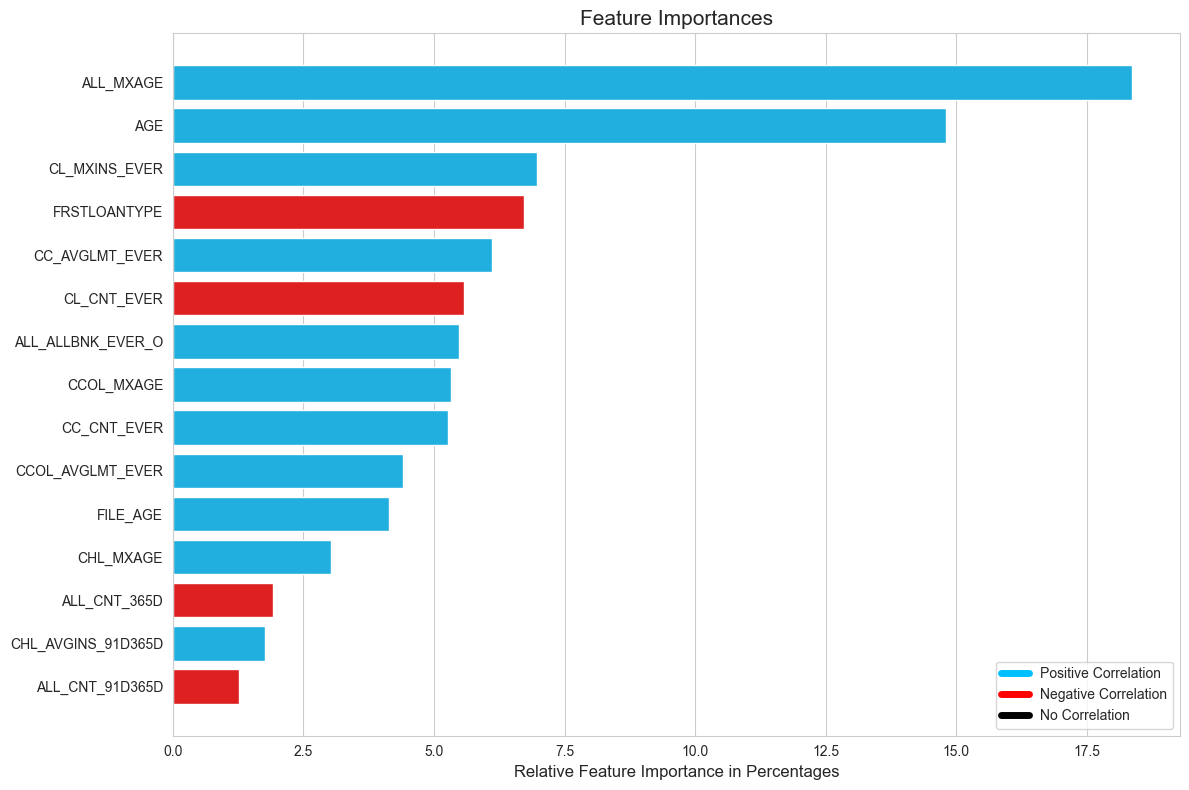

In [8]:
############ TRAIN MODEL ############

pipeline_base = Pipeline_Base()
pipeline_base.train(x_train = x_train, 
                    y_train = y_train,
                    x_test = x_test, 
                    y_test = y_test)

c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:208: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x, y=y, palette=colors)


drop_null_eliminated_features: 1391
drop_constant_eliminated_features: 1152
low_gini_eliminated_features: 80
correlation_elimination_eliminated_features: 44
used features: 38


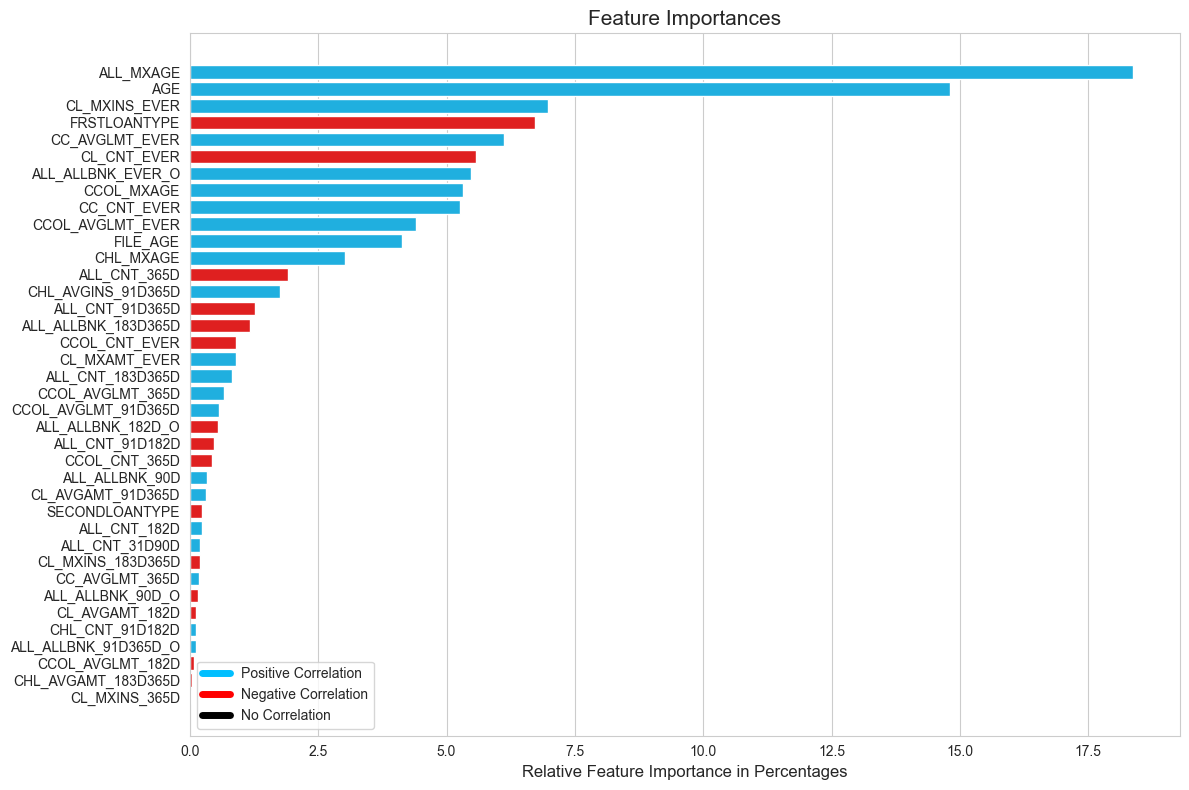

In [9]:
############ SAVE MODEL ############

model_path = f'Models/base_model_{version}.pkl'
with open(model_path, 'wb') as out:
    pickle.dump(pipeline_base.pipeline, out, pickle.HIGHEST_PROTOCOL)


############ LOAD MODEL ############

# model_path = f'Models/base_model_{version}.pkl'
# with open(model_path, 'rb') as f:
#   pipeline_base = pickle.load(f)


############ FEATURE IMPORTANCE ############
plot_feature_importances(df=pipeline_base.pipeline.logistic_regression_model.model.feature_importances,
                          n=50,
                          save_figure=True,
                          name_ext=f"Base_{version}")


feature_importances = pipeline_base.pipeline.logistic_regression_model.model.feature_importances
pd.DataFrame(feature_importances).to_excel(f"Output/FEATURE_IMPORTANCES_BASE_{version}.xlsx")



binning_table = pipeline_base.pipeline.monotonic_binning.get_binning_table()
pd.DataFrame(binning_table[0]).to_excel(f"Output/BINNING_TABLE_BASE_{version}.xlsx")
pd.DataFrame(binning_table[1]).to_excel(f"Output/GINI_TABLE_BASE_{version}.xlsx")





############ ELIMINATED FEATURES ############

variable_table = pipeline_base.pipeline.variable_table
pd.DataFrame(variable_table).to_excel(f"Output/FEATURES_BASE_{version}.xlsx")


drop_null_eliminated_features = pipeline_base.pipeline.eliminated_features['drop_null_features']
drop_constant_eliminated_features = pipeline_base.pipeline.eliminated_features['drop_constant_features']
low_gini_eliminated_features = pipeline_base.pipeline.eliminated_features['drop_low_gini_features']
correlation_elimination_eliminated_features = pipeline_base.pipeline.eliminated_features['correlated_lower_gini_feature_elimination']
pd.DataFrame(drop_null_eliminated_features, columns=["NULL_ELIMINATED_FEATURES"]).to_excel(f"Output/NULL_ELIMINATED_FEATURES_BASE_{version}.xlsx")
pd.DataFrame(drop_constant_eliminated_features, columns=["CONSTANT_ELIMINATED_FEATURES"]).to_excel(f"Output/CONSTANT_ELIMINATED_FEATURES_BASE_{version}.xlsx")
pd.DataFrame(low_gini_eliminated_features, columns=["GINI_ELIMINATED_FEATURES"]).to_excel(f"Output/GINI_ELIMINATED_FEATURES_BASE_{version}.xlsx")
pd.DataFrame(correlation_elimination_eliminated_features, columns=["CORR_ELIMINATED_FEATURES"]).to_excel(f"Output/CORR_ELIMINATED_FEATURES_BASE_{version}.xlsx")


print(
"""drop_null_eliminated_features: %d
drop_constant_eliminated_features: %d
low_gini_eliminated_features: %d
correlation_elimination_eliminated_features: %d
used features: %d""" % (len(drop_null_eliminated_features), len(drop_constant_eliminated_features), len(low_gini_eliminated_features), len(correlation_elimination_eliminated_features), sum(variable_table.use == True)))

In [10]:
############ PERFORMANCE OF THE BASE MODEL (LAYER_1) ############

############ BASIC PIPELINE RESULTS ############

base_test_proba_dict = pipeline_base.apply(x_test, y_test)
base_test_proba = base_test_proba_dict["".join(key for key in base_test_proba_dict if "Logistic Regression" in key)][0]

2025-11-26 15:01:07,691 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 15:01:07,847 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 15:01:09,361 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-26 15:01:09,362 - qnbanalytics - INFO - Train gini: 0.5209254440967059
2025-11-26 15:01:09,362 - qnbanalytics - INFO - CV gini: 0.5071116947818484
2025-11-26 15:01:09,363 - qnbanalytics - INFO - Valid gini: 0.35402507731449706
2025-11-26 15:01:09,364 - qnbanalytics - INFO - Test gini: 0.35402507731449706



In [11]:
############ CALCULATE CREDIT SCORES ############

# FIX: Score train and test SEPARATELY to eliminate data leakage
# Get train predictions
train_result = pipeline_base.apply(x_train, y_train)
lr_keys = [key for key in train_result.keys() if "Logistic Regression" in key]
if not lr_keys:
    raise KeyError(f"No 'Logistic Regression' key found. Available keys: {list(train_result.keys())}")
base_train_proba = train_result[lr_keys[0]][0]
base_train_proba = pd.DataFrame(base_train_proba, index = y_train.index)

# Get test predictions  
test_result = pipeline_base.apply(x_test, y_test)
lr_keys = [key for key in test_result.keys() if "Logistic Regression" in key]
if not lr_keys:
    raise KeyError(f"No 'Logistic Regression' key found. Available keys: {list(test_result.keys())}")
base_test_proba = test_result[lr_keys[0]][0]
base_test_proba = pd.DataFrame(base_test_proba, index = y_test.index)

# Combine for scoring output (but models were scored separately!)
base_all_proba = pd.concat([base_train_proba, base_test_proba], axis=0)
all_y = pd.concat([y_train, y_test], axis=0)


ref=200
odds_at_ref=50
points_to_double=20


default_rate = base_all_proba
default_rate = np.where(default_rate == 0, 0.00001, default_rate)

odds = (1/default_rate)-1

base_all_score = ((np.log(odds)-np.log(odds_at_ref))/np.log(2)) * (points_to_double) + ref
base_all_score = pd.DataFrame(base_all_score, index = all_y.index)



base_all_scores = pd.concat([base_all_proba, base_all_score, all_y], axis = 1)
base_all_scores.columns = ["PROBA","SCORE","TARGET"]
pd.DataFrame(base_all_scores).to_excel(f"Output/MAIN_SCORES_BASE_{version}.xlsx")

print("Base model took: %s" % (datetime.datetime.now()- start_time))

2025-11-26 15:01:10,892 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 15:01:11,021 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 15:01:12,611 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-26 15:01:12,613 - qnbanalytics - INFO - Train gini: 0.5209254440967059
2025-11-26 15:01:12,616 - qnbanalytics - INFO - CV gini: 0.5071116947818484
2025-11-26 15:01:12,618 - qnbanalytics - INFO - Valid gini: 0.35402507731449706
2025-11-26 15:01:12,620 - qnbanalytics - INFO - Test gini: 0.5209254440967059

2025-11-26 15:01:14,103 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 15:01:14,252 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 15:01:15,848 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-26 15:01:15,849 - qnbanalytics - INFO - Train gini: 0.5209254440967059
2025-11-26 15:01:15,850 - qnbanalytics - INFO - CV gini: 0.5071116947818484
2025-11-26 15:01:15,851 - qnbanalytics - INFO - V

Base model took: 0:02:18.629062


LAYER 2 MODEL TRAINING - DATA LEAKAGE FIX APPLIED

[1/4] Splitting training data for Layer 2...
Creating train_base (80%) and validation (20%) sets
Layer 2 segments will be created from VALIDATION set (no leakage!)
[OK] Train_base: 39,848 samples, 2.28% default rate
[OK] Validation: 9,963 samples, 2.28% default rate

[2/4] Re-training base model on train_base (80% of training data)...
This ensures Layer 2 segments are created without data leakage


2025-11-26 15:01:32,783 - qnbanalytics - INFO - There might be multiple ID in dataframe
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
2025-11-26 15:01:38,589 - qnbanalytics - INFO - Data Type Conversion started
2025-11-26 15:01:38,592 - qnbanalytics - INFO - Data Type Conversion completed
2025-11-26 15:01:41,333 - qnbanalytics - INFO - Feature Elimination Started: drop_null_features
2025-11-26 15:01:49,383 - qnbanalytics - INFO - Feature Elimination completed.
2025-11-26 15:01:52,799 - qnbanalytics - INFO - No ID detected!
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /=

Fitting WOE encoding for 162 variables using category_encoders.WOEEncoder...
Calculating Gini scores for all features...
WOE encoding fitted for 162 variables


2025-11-26 15:02:09,922 - qnbanalytics - INFO - Opt binning completed... 
2025-11-26 15:02:10,266 - qnbanalytics - INFO - No ID detected!
2025-11-26 15:02:10,693 - qnbanalytics - INFO - Data Type Conversion started
2025-11-26 15:02:10,695 - qnbanalytics - INFO - Data Type Conversion completed
2025-11-26 15:02:10,778 - qnbanalytics - INFO - Feature Elimination Started: drop_low_gini_features
2025-11-26 15:02:13,569 - qnbanalytics - INFO - Feature Elimination completed.
2025-11-26 15:02:13,756 - qnbanalytics - INFO - No ID detected!
2025-11-26 15:02:13,944 - qnbanalytics - INFO - Data Type Conversion started
2025-11-26 15:02:13,946 - qnbanalytics - INFO - Data Type Conversion completed
2025-11-26 15:02:14,005 - qnbanalytics - INFO - Feature Elimination Started: correlated_lower_gini_feature_elimination
c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\elimination.py:461: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

Fitting 3 folds for each of 1 candidates, totalling 3 fits


...


[3/4] Creating Layer 2 segments from validation set...


2025-11-26 15:02:18,631 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 15:02:18,657 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 15:02:19,197 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-26 15:02:19,199 - qnbanalytics - INFO - Train gini: 0.525990176550041
2025-11-26 15:02:19,200 - qnbanalytics - INFO - CV gini: 0.511522696101326
2025-11-26 15:02:19,201 - qnbanalytics - INFO - Valid gini: 0.34317689703165
2025-11-26 15:02:19,203 - qnbanalytics - INFO - Test gini: 0.4609406390380042



[OK] Not Good segment: 3,971 samples
[OK] Good segment: 8,245 samples

Not Good split (from validation set - no leakage):
        count  proportion
TARGET                   
0        3801     0.95719
1         170     0.04281

Good split (from validation set - no leakage):
        count  proportion
TARGET                   
0        8122    0.985082
1         123    0.014918

[4/4] Creating Layer 2 test segments...


2025-11-26 15:02:21,026 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 15:02:21,144 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 15:02:22,666 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-26 15:02:22,667 - qnbanalytics - INFO - Train gini: 0.525990176550041
2025-11-26 15:02:22,668 - qnbanalytics - INFO - CV gini: 0.511522696101326
2025-11-26 15:02:22,669 - qnbanalytics - INFO - Valid gini: 0.34317689703165
2025-11-26 15:02:22,671 - qnbanalytics - INFO - Test gini: 0.34317689703165



[OK] Test Not Good: 14,473 samples
[OK] Test Good: 41,582 samples

LAYER 2 SETUP COMPLETE - DATA LEAKAGE ELIMINATED
Expected: Layer 2 models will have POSITIVE CV Gini scores
Expected: Layer 2 test performance will be much better


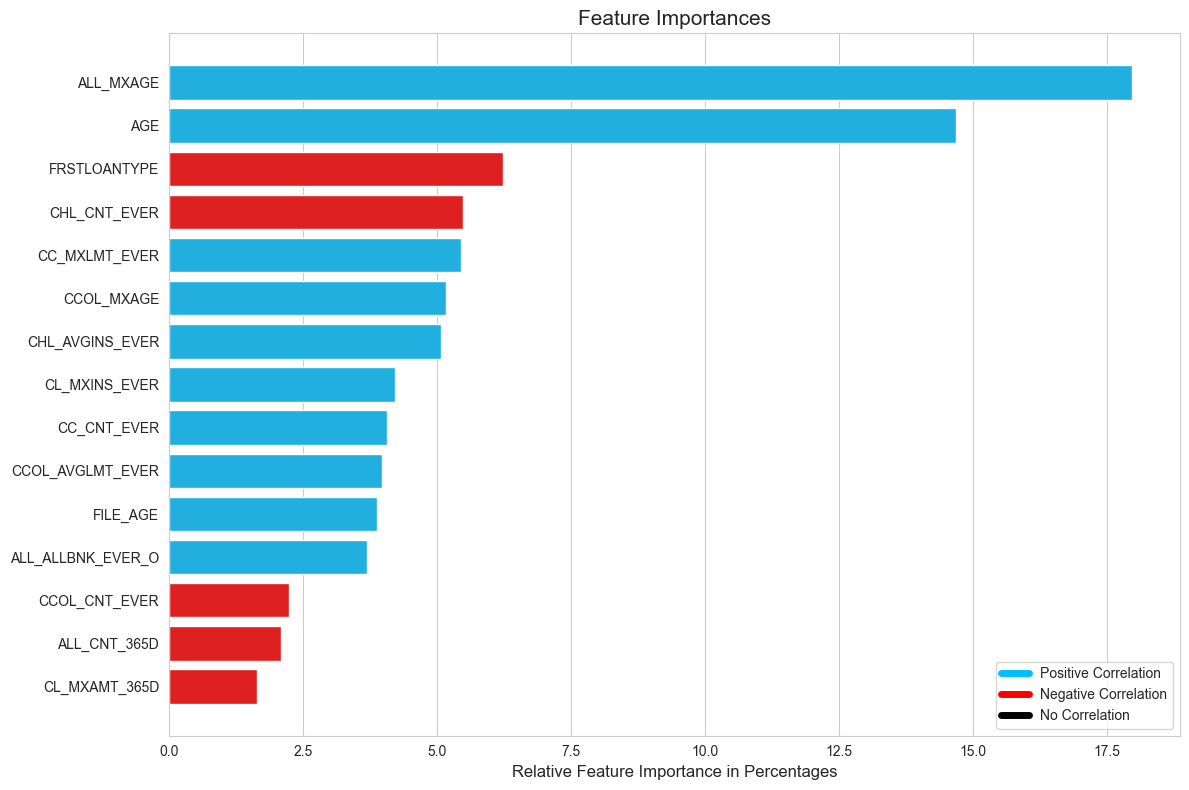

In [12]:
############ LAYER 2 SETUP - WITH DATA LEAKAGE FIX ############

print("=" * 70)
print("LAYER 2 MODEL TRAINING - DATA LEAKAGE FIX APPLIED")
print("=" * 70)

# Score calibration parameters
ref = 200
odds_at_ref = 50
points_to_double = 20

good_score_threshold = 180  # goods: 180+ scores
not_good_score_threshold = 200  # not_goods: 200- scores
good_threshold = 1 / (np.exp((good_score_threshold-ref) / (points_to_double) * np.log(2) + np.log(odds_at_ref)) + 1)
not_good_threshold = 1 / (np.exp((not_good_score_threshold-ref) / (points_to_double) * np.log(2) + np.log(odds_at_ref)) + 1)

# CRITICAL FIX: Split x_train into train_base and validation
# This prevents data leakage in Layer 2 segment creation
from sklearn.model_selection import train_test_split

print("\n[1/4] Splitting training data for Layer 2...")
print("Creating train_base (80%) and validation (20%) sets")
print("Layer 2 segments will be created from VALIDATION set (no leakage!)")

x_train_base, x_val, y_train_base, y_val = train_test_split(
    x_train, y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train  # Maintain default rate
)

train_base = train.loc[y_train_base.index]
val = train.loc[y_val.index]

print(f"[OK] Train_base: {x_train_base.shape[0]:,} samples, {y_train_base.mean():.2%} default rate")
print(f"[OK] Validation: {x_val.shape[0]:,} samples, {y_val.mean():.2%} default rate")

# Retrain base model on train_base ONLY (not full x_train!)
print("\n[2/4] Re-training base model on train_base (80% of training data)...")
print("This ensures Layer 2 segments are created without data leakage")

pipeline_base_for_layer2 = Pipeline_Base()
pipeline_base_for_layer2.train(x_train=x_train_base, y_train=y_train_base,
                               x_test=x_test, y_test=y_test)

# Get predictions on VALIDATION set (NO LEAKAGE!)
print("\n[3/4] Creating Layer 2 segments from validation set...")
val_preds = pipeline_base_for_layer2.apply(x_val, y_val)
lr_keys = [key for key in val_preds.keys() if "Logistic Regression" in key]
if not lr_keys:
    raise KeyError(f"No 'Logistic Regression' key found. Available keys: {list(val_preds.keys())}")
lr_key = lr_keys[0]

not_good_indices = val_preds[lr_key][0] >= not_good_threshold
good_indices = val_preds[lr_key][0] < good_threshold

print(f"[OK] Not Good segment: {not_good_indices.sum():,} samples")
print(f"[OK] Good segment: {good_indices.sum():,} samples")

# Create Layer 2 training sets from VALIDATION split
val_not_good = val[not_good_indices]
val_good = val[good_indices]

y_train_not_good = val_not_good["TARGET"]
y_train_good = val_good["TARGET"]

cols_to_drop_existing = [col for col in cols_to_drop if col in val_not_good.columns]
x_train_not_good = val_not_good.drop(columns=["TARGET"]+cols_to_drop_existing, inplace=False)
x_train_good = val_good.drop(columns=["TARGET"]+cols_to_drop_existing, inplace=False)

print("\nNot Good split (from validation set - no leakage):")
print(pd.concat([val_not_good.TARGET.value_counts(), 
                 val_not_good.TARGET.value_counts(normalize=True)], axis=1))
print("\nGood split (from validation set - no leakage):")
print(pd.concat([val_good.TARGET.value_counts(), 
                 val_good.TARGET.value_counts(normalize=True)], axis=1))

# Create test segments using base model predictions
print("\n[4/4] Creating Layer 2 test segments...")
test_preds = pipeline_base_for_layer2.apply(x_test=x_test, y_test=y_test)
lr_keys = [key for key in test_preds.keys() if "Logistic Regression" in key]
lr_key = lr_keys[0]

not_good_indices_test = test_preds[lr_key][0] >= not_good_threshold
good_indices_test = test_preds[lr_key][0] < good_threshold

test_not_good = test[not_good_indices_test]
test_good = test[good_indices_test]

y_test_not_good = test_not_good["TARGET"]
y_test_good = test_good["TARGET"]

cols_to_drop_existing_test = [col for col in cols_to_drop if col in test_not_good.columns]
x_test_not_good = test_not_good.drop(columns=["TARGET"]+cols_to_drop_existing_test, inplace=False)
x_test_good = test_good.drop(columns=["TARGET"]+cols_to_drop_existing_test, inplace=False)

print(f"[OK] Test Not Good: {x_test_not_good.shape[0]:,} samples")
print(f"[OK] Test Good: {x_test_good.shape[0]:,} samples")

print("\n" + "=" * 70)
print("LAYER 2 SETUP COMPLETE - DATA LEAKAGE ELIMINATED")
print("=" * 70)
print("Expected: Layer 2 models will have POSITIVE CV Gini scores")
print("Expected: Layer 2 test performance will be much better")
print("=" * 70)

In [13]:
############ CREATE PIPELINE FOR LAYER_2 MODELS ############

apply_data_explore = True
apply_null_elimination = True
apply_constant_elimination = True
apply_null_imputation = True          # BEFORE binning
apply_binning = True                   # PRIMARY encoding method
apply_low_gini_elimination = True      # AFTER binning
apply_correlated_feature_elimination = True
apply_scaling = False                  # For Layer 1 (Base)
apply_categorical_encoding = False     # SKIP - binning handles encoding!
apply_scaling = True
apply_LR = True
apply_RF = True   # Layer 2 only
apply_XGB = True  # Layer 2 only
apply_LGBM = True # Layer 2 only

In [14]:
class Pipeline_Not_Good:
    """
    Not Good segment pipeline - SAME ORDER as Base
    """

    def train(self, x_train, y_train, x_test=[], y_test=[]):
        if (len(x_test) > 0) & (len(y_test) > 0):
            x_val = x_test.copy()
            y_val = y_test.copy()

        self.pipeline = skills_api.ClassifierPipeline(x_train, y_train, x_val, y_val)

        ########################   Data Explore    ############################

        if apply_data_explore:
            self.pipeline.data_explore()


        ########################   Drop Null Features    ############################

        if apply_null_elimination:
            self.pipeline.feature_elimination(eliminator='drop_null_features', params={'threshold': 0.99})


        ########################   Drop Constant Features    ############################

        if apply_constant_elimination:
            self.pipeline.feature_elimination(eliminator='drop_constant_features', params={'missing_values':'ignore'})


        ########################   Null Imputation    ############################
        # BEFORE binning

        if apply_null_imputation:
            self.pipeline.null_imputation()


        ########################   Binning (WOE Encoding)    ############################
        # PRIMARY encoding - BEFORE elimination

        if apply_binning:
            self.pipeline.binning()


        ########################   Low Gini Elimination    ############################
        # AFTER binning

        if apply_low_gini_elimination:
            self.pipeline.feature_elimination(eliminator='drop_low_gini_features', params={'threshold':0.05, 'missing_values':'ignore'})


        ########################   Feature Elimination    ############################

        if apply_correlated_feature_elimination:
            self.pipeline.feature_elimination(eliminator='correlated_lower_gini_feature_elimination', params={'missing_values':'ignore'})


        ########################   Scaling    ############################
        # For Layer 2, scaling is typically enabled

        if apply_scaling:
            self.pipeline.scaling()


        ########################   Categorical Encoding    ############################
        # SKIP - binning handles it

        # if apply_categorical_encoding and not apply_binning:
        #     self.pipeline.encode_categoricals()


        #########################      Logistic Regression      #############################

        if apply_LR:
            self.pipeline.LogisticRegression(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['logistic_regression_not_good'])

        #########################      Random Forest      #############################

        if apply_RF:
            self.pipeline.RandomForest(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['random_forest_not_good'])

        #########################        XGBoost          #############################

        if apply_XGB:
            self.pipeline.XGBoost(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['xgboost_not_good'])

        #########################      LGBM      #############################

        if apply_LGBM:
            self.pipeline.LGBM(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['lightgbm_not_good'])

    def apply(self, x_test, y_test=[]):
        predicts = self.pipeline.test(test = x_test, y_test=y_test)
        return predicts

In [ ]:
class Pipeline_Good:
    """
    Good segment pipeline - SAME ORDER as Base
    """

    def train(self, x_train, y_train, x_test=[], y_test=[]):
        if (len(x_test) > 0) & (len(y_test) > 0):
            x_val = x_test.copy()
            y_val = y_test.copy()

        self.pipeline = skills_api.ClassifierPipeline(x_train, y_train, x_val, y_val)

        ########################   Data Explore    ############################

        if apply_data_explore:
            self.pipeline.data_explore()


        ########################   Drop Null Features    ############################

        if apply_null_elimination:
            self.pipeline.feature_elimination(eliminator='drop_null_features', params={'threshold': 0.99})


        ########################   Drop Constant Features    ############################

        if apply_constant_elimination:
            self.pipeline.feature_elimination(eliminator='drop_constant_features', params={'missing_values':'ignore'})


        ########################   Null Imputation    ############################
        # BEFORE binning

        if apply_null_imputation:
            self.pipeline.null_imputation()


        ########################   Binning (WOE Encoding)    ############################
        # PRIMARY encoding - BEFORE elimination

        if apply_binning:
            self.pipeline.binning()


        ########################   Low Gini Elimination    ############################
        # AFTER binning

        if apply_low_gini_elimination:
            self.pipeline.feature_elimination(eliminator='drop_low_gini_features', params={'threshold':0.05, 'missing_values':'ignore'})


        ########################   Feature Elimination    ############################

        if apply_correlated_feature_elimination:
            self.pipeline.feature_elimination(eliminator='correlated_lower_gini_feature_elimination', params={'missing_values':'ignore'})


        ########################   Scaling    ############################
        # For Layer 2, scaling is typically enabled

        if apply_scaling:
            self.pipeline.scaling()


        ########################   Categorical Encoding    ############################
        # SKIP - binning handles it

        # if apply_categorical_encoding and not apply_binning:
        #     self.pipeline.encode_categoricals()


        #########################      Logistic Regression      #############################

        if apply_LR:
            self.pipeline.LogisticRegression(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['logistic_regression_good'])

        #########################      Random Forest      #############################

        if apply_RF:
            self.pipeline.RandomForest(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['random_forest_good'])

        #########################        XGBoost          #############################

        if apply_XGB:
            self.pipeline.XGBoost(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['xgboost_good'])

        #########################      LGBM      #############################

        if apply_LGBM:
            self.pipeline.LGBM(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['lightgbm_good'])

    def apply(self, x_test, y_test=[]):
        predicts = self.pipeline.test(test = x_test, y_test=y_test)
        return predicts


2025-11-26 15:02:26,594 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 15:02:26,728 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 15:02:28,304 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-26 15:02:28,306 - qnbanalytics - INFO - Train gini: 0.5209254440967059
2025-11-26 15:02:28,306 - qnbanalytics - INFO - CV gini: 0.5071116947818484
2025-11-26 15:02:28,309 - qnbanalytics - INFO - Valid gini: 0.35402507731449706
2025-11-26 15:02:28,311 - qnbanalytics - INFO - Test gini: 0.35402507731449706

2025-11-26 15:02:32,246 - qnbanalytics - INFO - There might be multiple ID in dataframe
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Fitting WOE encoding for 169 variables using category_encoders.WOEEncoder...
Calculating Gini scores for all features...
WOE encoding fitted for 169 variables


2025-11-26 15:02:41,547 - qnbanalytics - INFO - Opt binning completed... 
2025-11-26 15:02:41,736 - qnbanalytics - INFO - No ID detected!
2025-11-26 15:02:41,845 - qnbanalytics - INFO - Data Type Conversion started
2025-11-26 15:02:41,847 - qnbanalytics - INFO - Data Type Conversion completed
2025-11-26 15:02:41,905 - qnbanalytics - INFO - Feature Elimination Started: drop_low_gini_features
2025-11-26 15:02:42,385 - qnbanalytics - INFO - Feature Elimination completed.
2025-11-26 15:02:42,454 - qnbanalytics - INFO - No ID detected!
2025-11-26 15:02:42,505 - qnbanalytics - INFO - Data Type Conversion started
2025-11-26 15:02:42,506 - qnbanalytics - INFO - Data Type Conversion completed
2025-11-26 15:02:42,527 - qnbanalytics - INFO - Feature Elimination Started: correlated_lower_gini_feature_elimination
c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\elimination.py:461: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

Fitting 3 folds for each of 1 candidates, totalling 3 fits
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier


c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:133: UserWarning: Model is linear, disabling fast option...
  warnings.warn("Model is linear, disabling fast option...") if fast else print("")
c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:138: UserWarning: Your model is LogisticRegression(C=0.02436512422392614, multi_class='auto', random_state=48)
  warnings.warn(f"""Your model is {model}""")
c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:139: UserWarning: If your model is not TreeBased, Linear or Deep Learning model, make sure to use agnostic option and give model as predict_proba function.
  warnings.warn(f"""If your model is not TreeBased, Linear or Deep Learning model, make sure to use agnostic option and give model as predict_proba function.""")
c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:208: FutureWarning: 

Passing `palette` without assigning `hu

...

2025-11-26 15:03:19,533 - qnbanalytics - INFO - Results of LGBMClassifier(colsample_bytree=0.8, early_stopping_round=10,
               first_metric_only=True, max_depth=6, min_child_samples=370,
               n_estimators=10000, n_jobs=1, num_leaves=12, random_state=48,
               reg_alpha=1.7786201857096935e-08,
               reg_lambda=0.0003320897385975011, silent='warn', subsample=0.9,
               subsample_freq=1)
2025-11-26 15:03:19,534 - qnbanalytics - INFO - Mean CV score:  0.6106426331670576
2025-11-26 15:03:19,537 - qnbanalytics - INFO - Calculating SHAP feature importances...
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\sklearn\base.py:1206: FutureWarning: passing a class to None is deprecated and will be removed in 1.8. Use an instance of the class instead.
  warnings.warn(


[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Info] Number of positive: 114, number of negative: 7307
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000944 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 502
[LightGBM] [Info] Number of data points in the train set: 7421, number of used features: 35
[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.015362 -> initscore=-4.160390
[LightGBM] [Info] Start training from score -4.160390
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[1]	valid_0's auc: 0.711111	valid_0's binary_logloss: 0.0602978
Training until validation scores don't improve for 10 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[2]	valid_0's auc: 0.771643	valid_0's binary_logloss: 0.0589129
[LightGBM] [Wa

c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:138: UserWarning: Your model is LGBMClassifier(colsample_bytree=0.8, early_stopping_round=10,
               first_metric_only=True, max_depth=6, min_child_samples=370,
               n_estimators=10000, n_jobs=1, num_leaves=12, random_state=48,
               reg_alpha=1.7786201857096935e-08,
               reg_lambda=0.0003320897385975011, silent='warn', subsample=0.9,
               subsample_freq=1)
  warnings.warn(f"""Your model is {model}""")
c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:139: UserWarning: If your model is not TreeBased, Linear or Deep Learning model, make sure to use agnostic option and give model as predict_proba function.
  warnings.warn(f"""If your model is not TreeBased, Linear or Deep Learning model, make sure to use agnostic option and give model as predict_proba function.""")
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\shap\

[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent


2025-11-26 15:03:20,912 - qnbanalytics - INFO - Results of LGBM
2025-11-26 15:03:20,913 - qnbanalytics - INFO - Train gini: 0.8730297916128631
2025-11-26 15:03:20,914 - qnbanalytics - INFO - CV gini: 0.6106426331670576
2025-11-26 15:03:20,915 - qnbanalytics - INFO - Valid gini: 0.12201424599820676
2025-11-26 15:03:20,917 - qnbanalytics - INFO - Test gini: None

2025-11-26 15:03:20,979 - qnbanalytics - INFO - No ID detected!


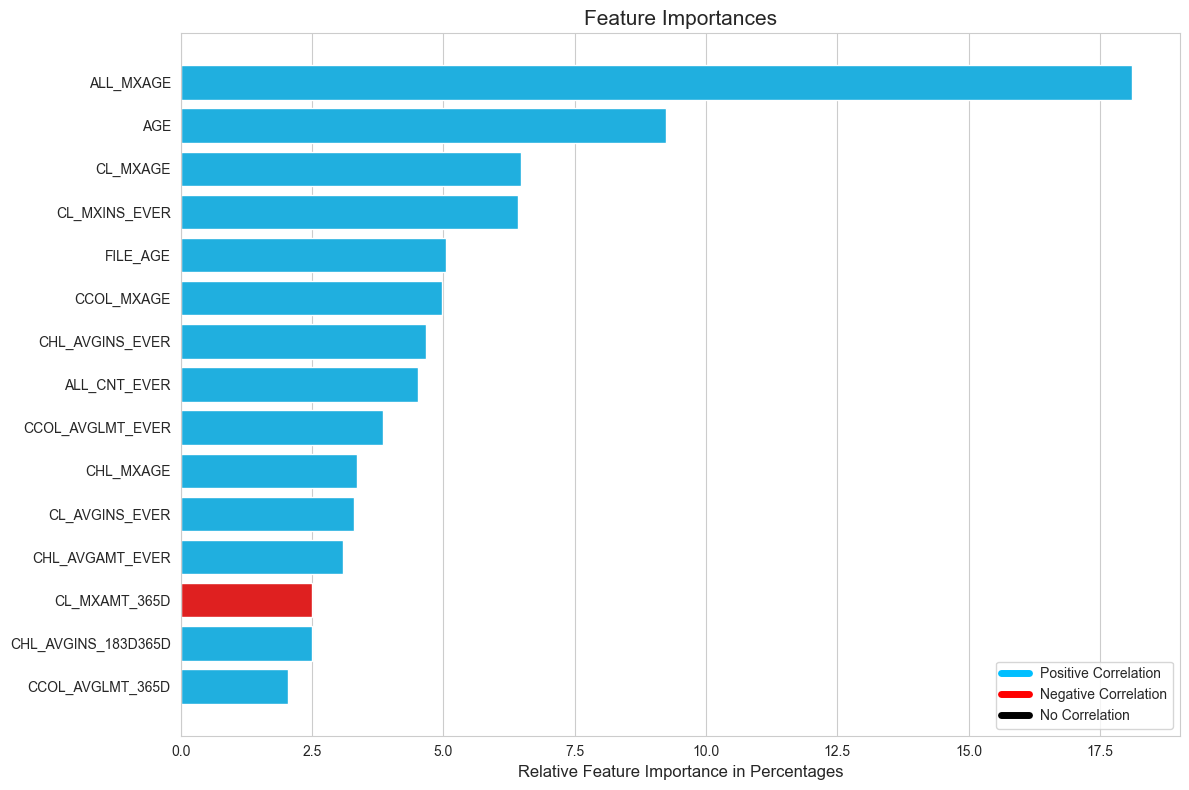

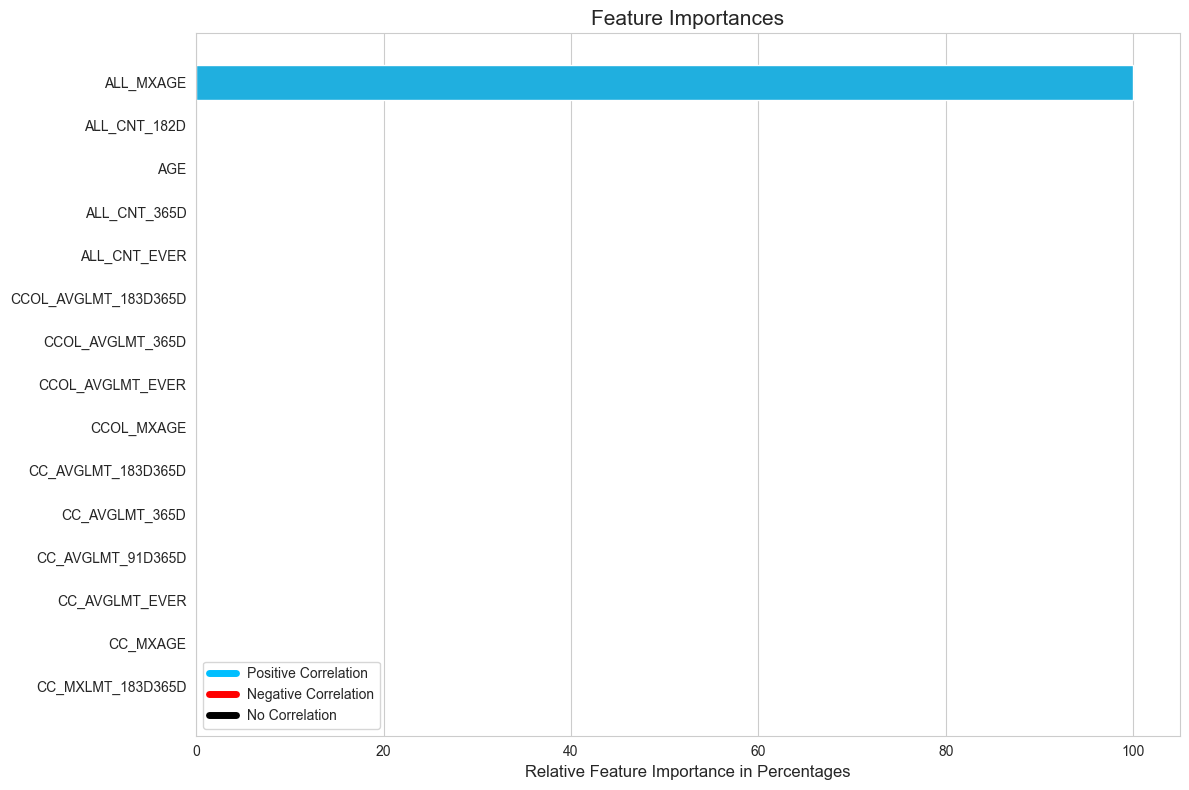

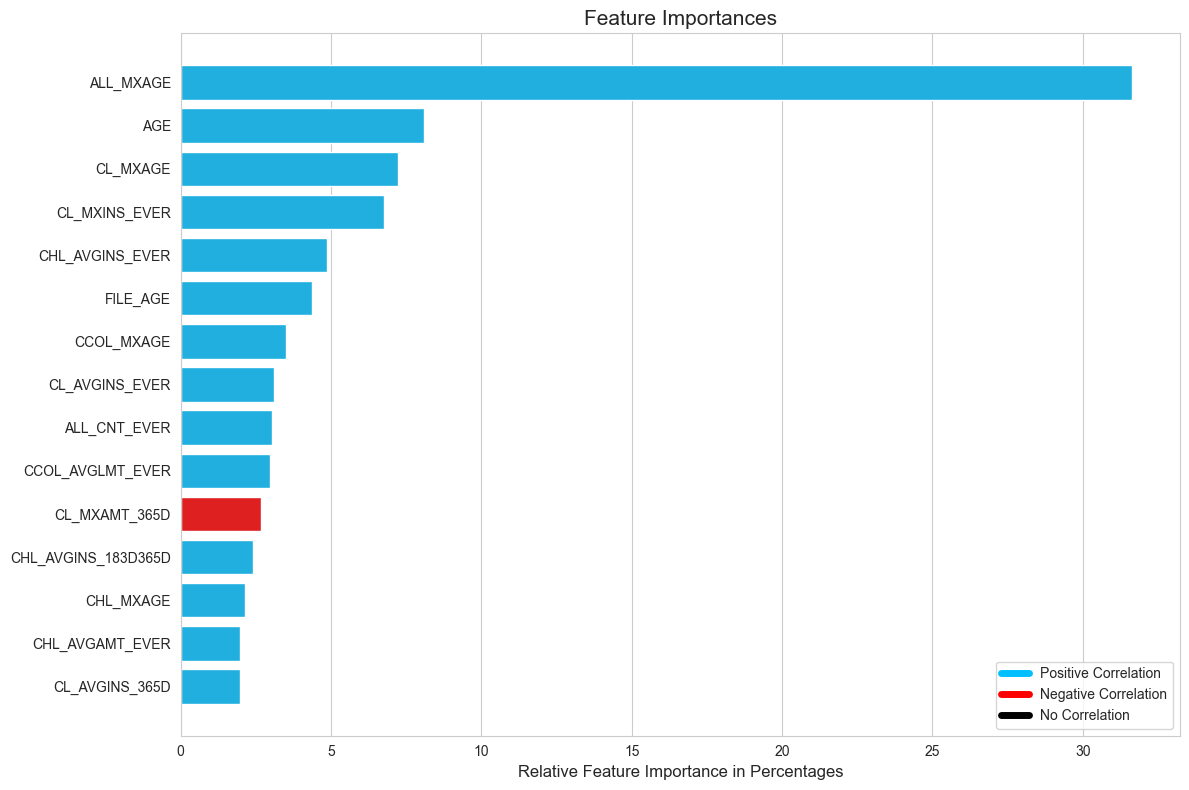

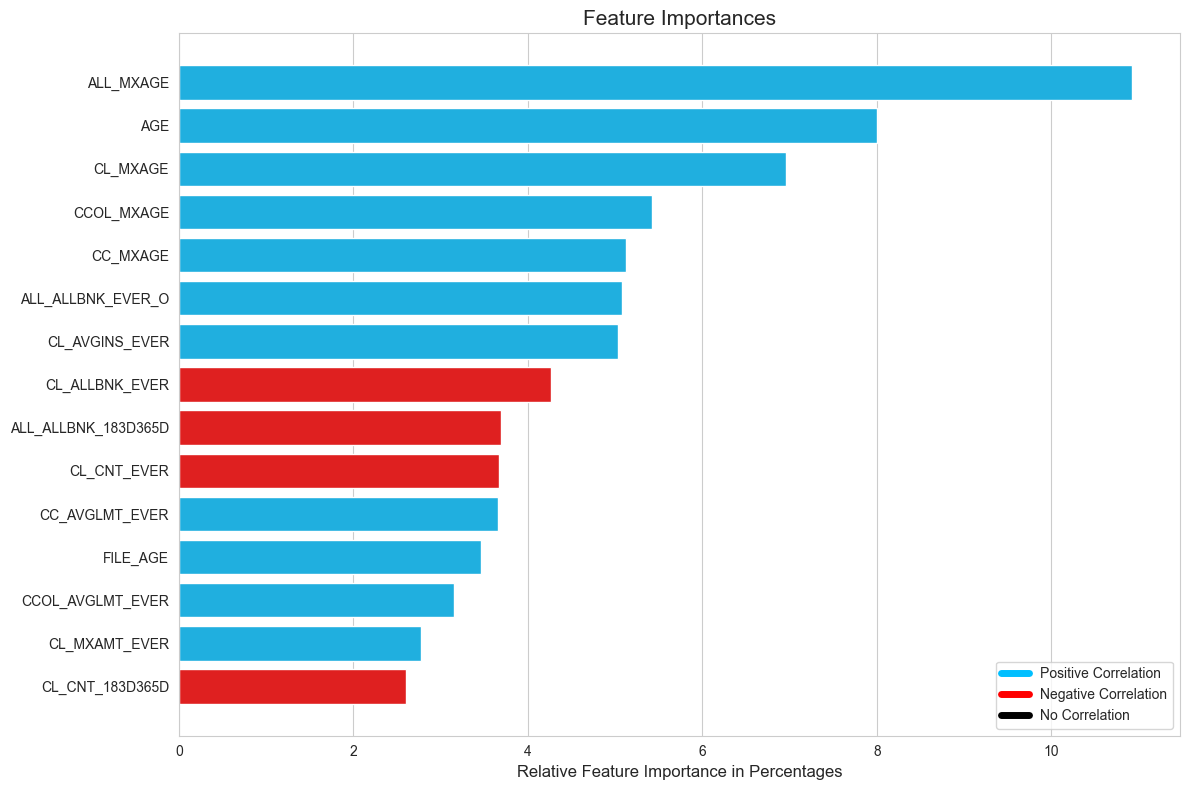

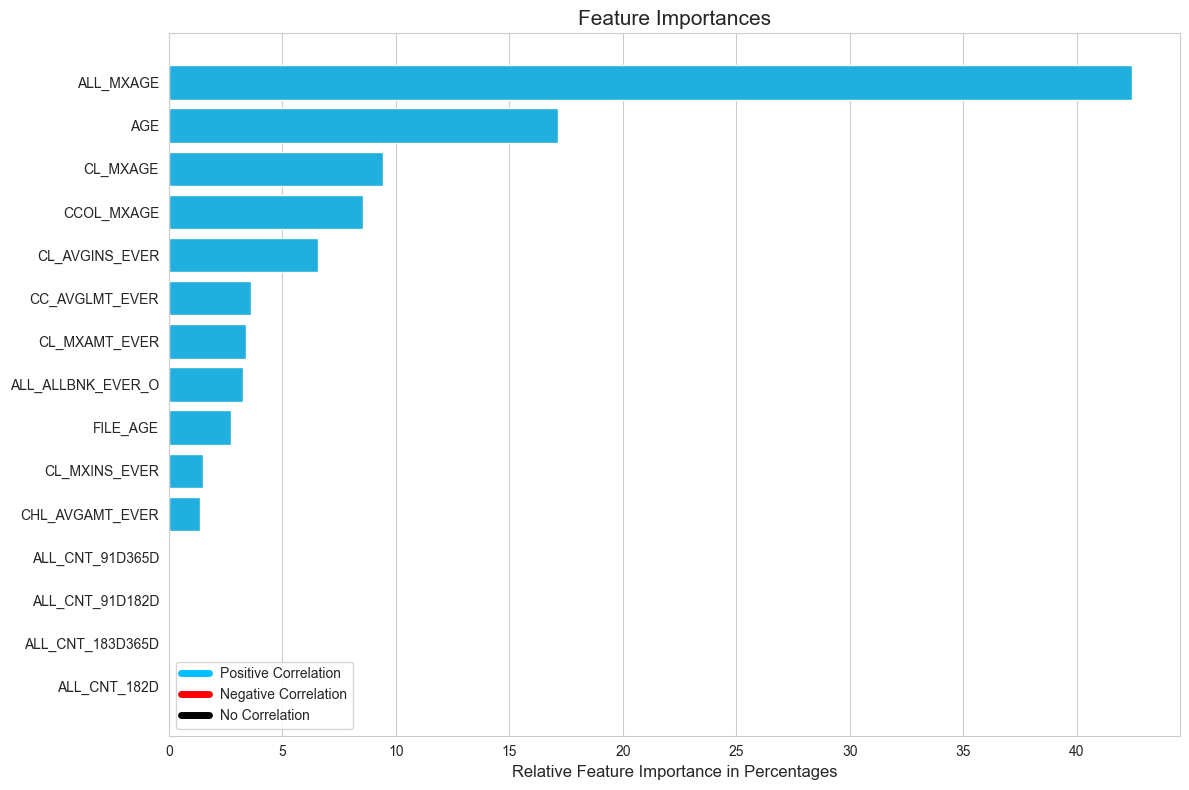

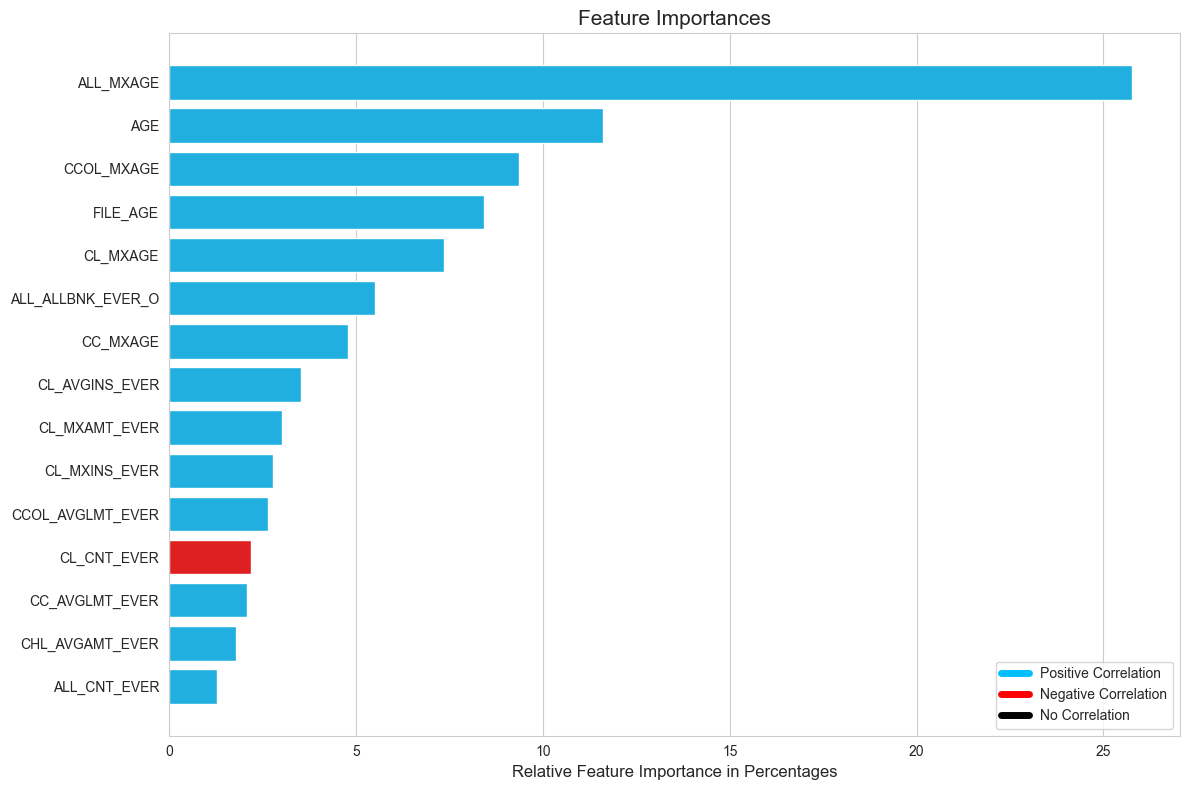

In [16]:
############ CREATE TEST DATA FOR LAYER_2 MODELS ############
# Get predictions (self-contained)
test_preds = pipeline_base.apply(x_test = x_test, y_test = y_test)
lr_keys = [key for key in test_preds.keys() if "Logistic Regression" in key]
if not lr_keys:
    raise KeyError(f"No 'Logistic Regression' key found. Available keys: {list(test_preds.keys())}")
lr_key = lr_keys[0]
not_good_indices_test = test_preds[lr_key][0] >= not_good_threshold
good_indices_test = test_preds[lr_key][0] < good_threshold

test_not_good = test[not_good_indices_test]
test_good = test[good_indices_test]

y_test_not_good = test_not_good["TARGET"]
y_test_good = test_good["TARGET"]

# Only drop columns that exist (safer approach)
cols_to_drop_existing_test = [col for col in cols_to_drop if col in test_not_good.columns]
x_test_not_good = test_not_good.drop(columns=["TARGET"]+cols_to_drop_existing_test, inplace=False)
x_test_good = test_good.drop(columns=["TARGET"]+cols_to_drop_existing_test, inplace=False)

############ TRAIN LAYER_2 MODELS ############

pipeline_not_good = Pipeline_Not_Good()
pipeline_not_good.train(x_train=x_train_not_good, y_train=y_train_not_good, x_test = x_test_not_good, y_test = y_test_not_good)

pipeline_good = Pipeline_Good()
pipeline_good.train(x_train=x_train_good, y_train=y_train_good, x_test = x_test_good, y_test = y_test_good)

In [17]:
############ SELECT BEST MODELS FOR LAYER_2 ############

pipeline_not_good.apply(x_test_not_good, y_test_not_good)
pipeline_good.apply(x_test_good, y_test_good)


2025-11-26 15:03:22,679 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 15:03:22,719 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 15:03:23,362 - qnbanalytics - INFO - Scaling started...

2025-11-26 15:03:23,366 - qnbanalytics - INFO - Scaling completed.

2025-11-26 15:03:23,382 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-26 15:03:23,384 - qnbanalytics - INFO - Train gini: 0.7397929337480849
2025-11-26 15:03:23,384 - qnbanalytics - INFO - CV gini: 0.6907893912629508
2025-11-26 15:03:23,386 - qnbanalytics - INFO - Valid gini: 0.10880345549268866
2025-11-26 15:03:23,387 - qnbanalytics - INFO - Test gini: 0.10880345549268866

2025-11-26 15:03:23,612 - qnbanalytics - INFO - Results of Random Forest
2025-11-26 15:03:23,614 - qnbanalytics - INFO - Train gini: 0.7460838479038026
2025-11-26 15:03:23,615 - qnbanalytics - INFO - CV gini: 0.5770398107871626
2025-11-26 15:03:23,616 - qnbanalytics - INFO - Valid gini: 0.08428150783881727


[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent


2025-11-26 15:03:25,225 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 15:03:25,323 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 15:03:26,722 - qnbanalytics - INFO - Scaling started...

2025-11-26 15:03:26,733 - qnbanalytics - INFO - Scaling completed.

2025-11-26 15:03:26,767 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-26 15:03:26,768 - qnbanalytics - INFO - Train gini: 0.7639023189049914
2025-11-26 15:03:26,769 - qnbanalytics - INFO - CV gini: 0.7090604762388126
2025-11-26 15:03:26,770 - qnbanalytics - INFO - Valid gini: 0.13109031083696654
2025-11-26 15:03:26,771 - qnbanalytics - INFO - Test gini: 0.13109031083696654

2025-11-26 15:03:27,198 - qnbanalytics - INFO - Results of Random Forest
2025-11-26 15:03:27,200 - qnbanalytics - INFO - Train gini: 0.7262288714982692
2025-11-26 15:03:27,201 - qnbanalytics - INFO - CV gini: 0.5874196514434245
2025-11-26 15:03:27,202 - qnbanalytics - INFO - Valid gini: 0.12150687280712669


[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent


{'15.Model: Logistic Regression': [array([0.00425791, 0.01657259, 0.00996936, ..., 0.01088087, 0.0029196 ,
         0.00532361], shape=(41737,)),
  array([0, 0, 0, ..., 0, 0, 0], shape=(41737,))],
 '17.Model: Random Forest': [array([0.00884476, 0.0113824 , 0.02024072, ..., 0.02016293, 0.0053799 ,
         0.00915132], shape=(41737,)),
  array([0, 0, 0, ..., 0, 0, 0], shape=(41737,))],
 '19.Model: XGBoost': [array([0.00920747, 0.02108775, 0.00881865, ..., 0.01997249, 0.00881865,
         0.00946614], shape=(41737,), dtype=float32),
  array([0, 0, 0, ..., 0, 0, 0], shape=(41737,))],
 '21.Model: LGBM': [array([0.00213924, 0.00911252, 0.00133673, ..., 0.01566123, 0.0014787 ,
         0.00239558], shape=(41737,)),
  array([0, 0, 0, ..., 0, 0, 0], shape=(41737,))]}

In [18]:
############ SAVE MODEL ############

model_path_not_good = f'Models/not_good_model_{version}.pkl'
model_path_good = f'Models/good_model_{version}.pkl'
with open(model_path_not_good, 'wb') as out:  pickle.dump(pipeline_not_good.pipeline, out, pickle.HIGHEST_PROTOCOL)
with open(model_path_good, 'wb') as out:  pickle.dump(pipeline_good.pipeline, out, pickle.HIGHEST_PROTOCOL)

In [19]:
############ SELECTED MODELS ############

not_good_selected_model = 'Logistic Regression'
good_selected_model = 'LGBM'

not_good_model = 'logistic_regression'
good_model = 'lgbm'


In [20]:
############ FEATURE IMPORTANCES AND ELIMINATED FEATURES ############

feature_importances_not_good = getattr(pipeline_not_good.pipeline, f'{not_good_model}_model').model.feature_importances
feature_importances_good = getattr(pipeline_good.pipeline, f'{good_model}_model').model.feature_importances

pd.DataFrame(feature_importances_not_good).to_excel(f"Output/FEATURE_IMPORTANCES_NOT_GOOD_{version}.xlsx")
pd.DataFrame(feature_importances_good).to_excel(f"Output/FEATURE_IMPORTANCES_GOOD_{version}.xlsx")

variable_table_not_good = pipeline_not_good.pipeline.variable_table
variable_table_good = pipeline_good.pipeline.variable_table
pd.DataFrame(variable_table_not_good).to_excel(f"Output/FEATURES_NOT_GOOD_{version}.xlsx")
pd.DataFrame(variable_table_good).to_excel(f"Output/FEATURES_GOOD_{version}.xlsx")

drop_null_eliminated_features_not_good = pipeline_not_good.pipeline.eliminated_features['drop_null_features']
drop_null_eliminated_features_good = pipeline_good.pipeline.eliminated_features['drop_null_features']
pd.DataFrame(drop_null_eliminated_features_not_good, columns=["NULL_ELIMINATED_FEATURES"]).to_excel(f"Output/NULL_ELIMINATED_FEATURES_NOT_GOOD_{version}.xlsx")
pd.DataFrame(drop_null_eliminated_features_good, columns=["NULL_ELIMINATED_FEATURES"]).to_excel(f"Output/NULL_ELIMINATED_FEATURES_GOOD_{version}.xlsx")

drop_null_eliminated_features_not_good = pipeline_not_good.pipeline.eliminated_features['drop_constant_features']
drop_null_eliminated_features_good = pipeline_good.pipeline.eliminated_features['drop_constant_features']
pd.DataFrame(drop_null_eliminated_features_not_good, columns=["CONSTANT_ELIMINATED_FEATURES"]).to_excel(f"Output/CONSTANT_ELIMINATED_FEATURES_NOT_GOOD_{version}.xlsx")
pd.DataFrame(drop_null_eliminated_features_good, columns=["CONSTANT_ELIMINATED_FEATURES"]).to_excel(f"Output/CONSTANT_ELIMINATED_FEATURES_GOOD_{version}.xlsx")

low_gini_eliminated_features_not_good = pipeline_not_good.pipeline.eliminated_features['drop_low_gini_features']
low_gini_eliminated_features_good = pipeline_good.pipeline.eliminated_features['drop_low_gini_features']
pd.DataFrame(low_gini_eliminated_features_not_good, columns=["GINI_ELIMINATED_FEATURES"]).to_excel(f"Output/GINI_ELIMINATED_FEATURES_NOT_GOOD_{version}.xlsx")
pd.DataFrame(low_gini_eliminated_features_good, columns=["GINI_ELIMINATED_FEATURES"]).to_excel(f"Output/GINI_ELIMINATED_FEATURES_GOOD_{version}.xlsx")

correlation_elimination_eliminated_features_not_good = pipeline_not_good.pipeline.eliminated_features['correlated_lower_gini_feature_elimination']
correlation_elimination_eliminated_features_good = pipeline_good.pipeline.eliminated_features['correlated_lower_gini_feature_elimination']
pd.DataFrame(correlation_elimination_eliminated_features_not_good, columns=["CORR_ELIMINATED_FEATURES"]).to_excel(f"Output/CORR_ELIMINATED_FEATURES_NOT_GOOD_{version}.xlsx")
pd.DataFrame(correlation_elimination_eliminated_features_good, columns=["CORR_ELIMINATED_FEATURES"]).to_excel(f"Output/CORR_ELIMINATED_FEATURES_GOOD_{version}.xlsx")

In [21]:
############ GENERATE FEATURES FOR LAYER_3 (META MODEL) ############

print("=" * 70)
print("GENERATING LAYER 3 FEATURES")
print("=" * 70)

# IMPORTANT: For Layer 3, we need to use the FULL training set
# We'll use the pipeline_base_for_layer2 model (trained on train_base)
# to generate features for the FULL training set

print("\n[1/2] Generating meta features for TRAINING set...")
print(f"Using full training set: {x_train.shape[0]:,} samples")

# Get base model predictions on FULL train set
base_train_proba_dict = pipeline_base_for_layer2.apply(x_train, y_train)
lr_keys = [key for key in base_train_proba_dict.keys() if "Logistic Regression" in key]
if not lr_keys:
    raise KeyError(f"No 'Logistic Regression' key found. Available keys: {list(base_train_proba_dict.keys())}")
base_train_proba = base_train_proba_dict[lr_keys[0]][0]

# Get Layer 2 model predictions on FULL train set
not_good_train_proba_dict = pipeline_not_good.apply(x_train, y_train)
ng_keys = [key for key in not_good_train_proba_dict.keys() if f"{not_good_selected_model}" in key]
if not ng_keys:
    raise KeyError(f"No '{not_good_selected_model}' key found. Available keys: {list(not_good_train_proba_dict.keys())}")
not_good_train_proba = not_good_train_proba_dict[ng_keys[0]][0]

good_train_proba_dict = pipeline_good.apply(x_train, y_train)
g_keys = [key for key in good_train_proba_dict.keys() if f"{good_selected_model}" in key]
if not g_keys:
    raise KeyError(f"No '{good_selected_model}' key found. Available keys: {list(good_train_proba_dict.keys())}")
good_train_proba = good_train_proba_dict[g_keys[0]][0]

# Create meta features
base_train_proba = pd.DataFrame(base_train_proba, index=y_train.index)
not_good_train_proba = pd.DataFrame(not_good_train_proba, index=y_train.index)
good_train_proba = pd.DataFrame(good_train_proba, index=y_train.index)

x_train_meta = pd.concat([base_train_proba, good_train_proba, not_good_train_proba], axis=1)
x_train_meta.columns = ["Base", "Good", "Not_Good"]
y_train_meta = y_train

print(f"[OK] Train meta features: {x_train_meta.shape}")
print(f"[OK] Feature ranges:")
print(f"     Base: [{x_train_meta['Base'].min():.4f}, {x_train_meta['Base'].max():.4f}]")
print(f"     Good: [{x_train_meta['Good'].min():.4f}, {x_train_meta['Good'].max():.4f}]")
print(f"     Not_Good: [{x_train_meta['Not_Good'].min():.4f}, {x_train_meta['Not_Good'].max():.4f}]")

print("\n[2/2] Generating meta features for TEST set...")

# Get predictions on test set
base_test_proba_dict = pipeline_base_for_layer2.apply(x_test, y_test)
lr_keys = [key for key in base_test_proba_dict.keys() if "Logistic Regression" in key]
base_test_proba = base_test_proba_dict[lr_keys[0]][0]

not_good_test_proba_dict = pipeline_not_good.apply(x_test, y_test)
ng_keys = [key for key in not_good_test_proba_dict.keys() if f"{not_good_selected_model}" in key]
not_good_test_proba = not_good_test_proba_dict[ng_keys[0]][0]

good_test_proba_dict = pipeline_good.apply(x_test, y_test)
g_keys = [key for key in good_test_proba_dict.keys() if f"{good_selected_model}" in key]
good_test_proba = good_test_proba_dict[g_keys[0]][0]

# Create meta features
base_test_proba = pd.DataFrame(base_test_proba, index=y_test.index)
good_test_proba = pd.DataFrame(good_test_proba, index=y_test.index)
not_good_test_proba = pd.DataFrame(not_good_test_proba, index=y_test.index)

x_test_meta = pd.concat([base_test_proba, good_test_proba, not_good_test_proba], axis=1)
x_test_meta.columns = ["Base", "Good", "Not_Good"]
y_test_meta = y_test

print(f"[OK] Test meta features: {x_test_meta.shape}")
print(f"[OK] Feature ranges:")
print(f"     Base: [{x_test_meta['Base'].min():.4f}, {x_test_meta['Base'].max():.4f}]")
print(f"     Good: [{x_test_meta['Good'].min():.4f}, {x_test_meta['Good'].max():.4f}]")
print(f"     Not_Good: [{x_test_meta['Not_Good'].min():.4f}, {x_test_meta['Not_Good'].max():.4f}]")

print("\n" + "=" * 70)
print("LAYER 3 FEATURES GENERATED")
print("=" * 70)

GENERATING LAYER 3 FEATURES

[1/2] Generating meta features for TRAINING set...
Using full training set: 49,811 samples


2025-11-26 15:03:32,448 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 15:03:32,585 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 15:03:34,208 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-26 15:03:34,210 - qnbanalytics - INFO - Train gini: 0.525990176550041
2025-11-26 15:03:34,211 - qnbanalytics - INFO - CV gini: 0.511522696101326
2025-11-26 15:03:34,213 - qnbanalytics - INFO - Valid gini: 0.34317689703165
2025-11-26 15:03:34,214 - qnbanalytics - INFO - Test gini: 0.5129745331684394

2025-11-26 15:03:35,763 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 15:03:35,896 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 15:03:37,705 - qnbanalytics - INFO - Scaling started...

2025-11-26 15:03:37,716 - qnbanalytics - INFO - Scaling completed.

2025-11-26 15:03:37,753 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-26 15:03:37,755 - qnbanalytics - INFO - Train gini: 0.73979293374

[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent


2025-11-26 15:03:40,109 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 15:03:40,217 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 15:03:41,767 - qnbanalytics - INFO - Scaling started...

2025-11-26 15:03:41,778 - qnbanalytics - INFO - Scaling completed.

2025-11-26 15:03:41,818 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-26 15:03:41,820 - qnbanalytics - INFO - Train gini: 0.7639023189049914
2025-11-26 15:03:41,821 - qnbanalytics - INFO - CV gini: 0.7090604762388126
2025-11-26 15:03:41,822 - qnbanalytics - INFO - Valid gini: 0.13109031083696654
2025-11-26 15:03:41,823 - qnbanalytics - INFO - Test gini: 0.35081409101292405

2025-11-26 15:03:42,318 - qnbanalytics - INFO - Results of Random Forest
2025-11-26 15:03:42,318 - qnbanalytics - INFO - Train gini: 0.7262288714982692
2025-11-26 15:03:42,319 - qnbanalytics - INFO - CV gini: 0.5874196514434245
2025-11-26 15:03:42,320 - qnbanalytics - INFO - Valid gini: 0.12150687280712669


[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent


...

[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent


2025-11-26 15:03:51,392 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 15:03:51,512 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 15:03:53,020 - qnbanalytics - INFO - Scaling started...

2025-11-26 15:03:53,032 - qnbanalytics - INFO - Scaling completed.

2025-11-26 15:03:53,077 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-26 15:03:53,078 - qnbanalytics - INFO - Train gini: 0.7639023189049914
2025-11-26 15:03:53,079 - qnbanalytics - INFO - CV gini: 0.7090604762388126
2025-11-26 15:03:53,080 - qnbanalytics - INFO - Valid gini: 0.13109031083696654
2025-11-26 15:03:53,081 - qnbanalytics - INFO - Test gini: 0.2123244035545171

2025-11-26 15:03:53,609 - qnbanalytics - INFO - Results of Random Forest
2025-11-26 15:03:53,611 - qnbanalytics - INFO - Train gini: 0.7262288714982692
2025-11-26 15:03:53,612 - qnbanalytics - INFO - CV gini: 0.5874196514434245
2025-11-26 15:03:53,613 - qnbanalytics - INFO - Valid gini: 0.12150687280712669
2

[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent


2025-11-26 15:03:53,959 - qnbanalytics - INFO - Results of LGBM
2025-11-26 15:03:53,960 - qnbanalytics - INFO - Train gini: 0.8730297916128631
2025-11-26 15:03:53,961 - qnbanalytics - INFO - CV gini: 0.6106426331670576
2025-11-26 15:03:53,962 - qnbanalytics - INFO - Valid gini: 0.12201424599820676
2025-11-26 15:03:53,962 - qnbanalytics - INFO - Test gini: 0.18562610866178764



[OK] Test meta features: (46516, 3)
[OK] Feature ranges:
     Base: [0.0009, 0.2020]
     Good: [0.0003, 0.4236]
     Not_Good: [0.0001, 0.6531]

LAYER 3 FEATURES GENERATED


In [22]:
############ CREATE PIPELINE AND TRAIN LAYER_3 MODEL ############

apply_data_explore = True
apply_null_elimination = True
apply_constant_elimination = True
apply_null_imputation = True          # BEFORE binning
apply_binning = True                   # PRIMARY encoding method
apply_low_gini_elimination = True      # AFTER binning
apply_correlated_feature_elimination = True
apply_scaling = False                  # For Layer 1 (Base)
apply_categorical_encoding = False     # SKIP - binning handles encoding!

apply_LR = True

In [23]:

class Pipeline_Meta:
    """
    Meta model pipeline - No preprocessing needed, just model training
    Features are already probabilities from Layer 1 and Layer 2
    """

    def train(self, x_train, y_train, x_test=[], y_test=[]):
        if (len(x_test) > 0) & (len(y_test) > 0):
            x_val = x_test.copy()
            y_val = y_test.copy()

        self.pipeline = skills_api.ClassifierPipeline(x_train, y_train, x_val, y_val)

        ########################   Data Explore    ############################

        if apply_data_explore:
            self.pipeline.data_explore()


        # NO PREPROCESSING for meta model - features are already probabilities
        # Skip: null elimination, constant elimination, imputation, binning, elimination


        #########################      Logistic Regression      #############################

        if apply_LR:
            self.pipeline.LogisticRegression(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['logistic_regression_meta'])


    def apply(self, x_test, y_test=[]):
        predicts = self.pipeline.test(test = x_test, y_test=y_test)
        return predicts



2025-11-26 15:03:54,061 - qnbanalytics - INFO - No ID detected!
2025-11-26 15:03:54,075 - qnbanalytics - INFO - Data Type Conversion started
2025-11-26 15:03:54,076 - qnbanalytics - INFO - Data Type Conversion completed
2025-11-26 15:03:54,082 - qnbanalytics - INFO - 

2025-11-26 15:03:54,083 - qnbanalytics - INFO - Logistic Regression fitting started.

2025-11-26 15:03:54,084 - qnbanalytics - INFO - This is a binary classification problem.

2025-11-26 15:03:54,154 - qnbanalytics - INFO - Parameter optimization started.

c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=15. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will al

Fitting 3 folds for each of 1 candidates, totalling 3 fits


c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
2025-11-26 15:03:54,496 - qnbanalytics - INFO - Refitting to all data...
c:\Users\iasamadov\Desktop\scoring_model\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
2025-11-26 15:03:54,611 - qnbanalytics - INFO - Results of LogisticRegression(C=80.16389938139379, multi_class='auto', random_state=48)
2025-11-26 15:03:54,612 - qnbanalytics - INFO - Mean CV score:  0.5434600208946341
2025-11-26 15:03:54,614 - qnbanalytics - INFO - Calculating SHAP feature importances...
c:

is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier


c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:133: UserWarning: Model is linear, disabling fast option...
  warnings.warn("Model is linear, disabling fast option...") if fast else print("")
c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:138: UserWarning: Your model is LogisticRegression(C=80.16389938139379, multi_class='auto', random_state=48)
  warnings.warn(f"""Your model is {model}""")
c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:139: UserWarning: If your model is not TreeBased, Linear or Deep Learning model, make sure to use agnostic option and give model as predict_proba function.
  warnings.warn(f"""If your model is not TreeBased, Linear or Deep Learning model, make sure to use agnostic option and give model as predict_proba function.""")
c:\Users\iasamadov\Desktop\scoring_model\QNBAnalytics_ML\feature_importances.py:208: FutureWarning: 

Passing `palette` without assigning `hue`

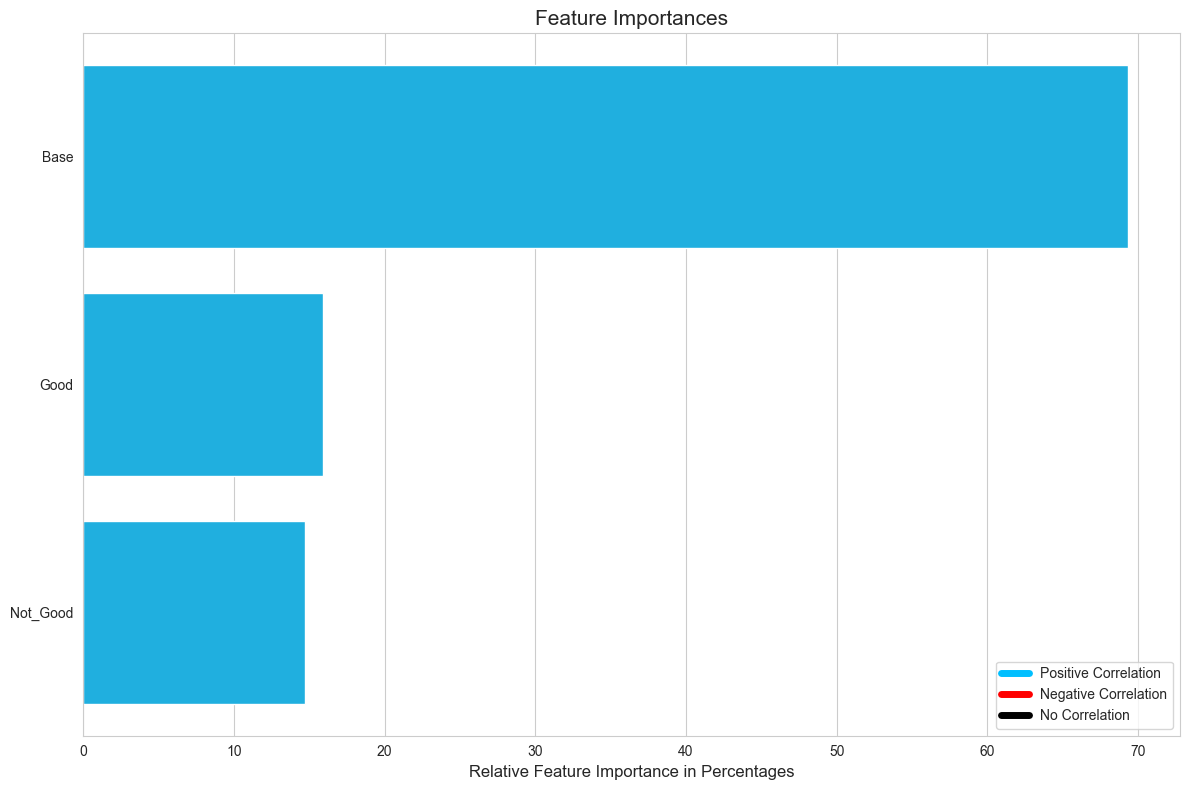

In [24]:
pipeline_meta = Pipeline_Meta()
pipeline_meta.train(x_train=x_train_meta, y_train=y_train_meta, x_test = x_test_meta, y_test = y_test_meta)

In [25]:
############ SAVE MODEL ############

model_path_meta = f'Models/meta_model_{version}.pkl'
with open(model_path_meta, 'wb') as out:
    pickle.dump(pipeline_meta.pipeline, out, pickle.HIGHEST_PROTOCOL)

In [26]:
############ ADVANCED PIPELINE RESULTS ############

meta_test_proba_dict = pipeline_meta.apply(x_test_meta, y_test_meta)
meta_test_proba = meta_test_proba_dict["".join(key for key in meta_test_proba_dict if "Logistic Regression" in key)][0]
meta_test_proba = pd.DataFrame(meta_test_proba, index = y_test_meta.index)

2025-11-26 15:03:55,664 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-26 15:03:55,665 - qnbanalytics - INFO - Train gini: 0.5359103007176893
2025-11-26 15:03:55,665 - qnbanalytics - INFO - CV gini: 0.5434600208946341
2025-11-26 15:03:55,666 - qnbanalytics - INFO - Valid gini: 0.33899157363703747
2025-11-26 15:03:55,668 - qnbanalytics - INFO - Test gini: 0.33899157363703747



In [27]:
############ APPLY TO ALL DATA ############

# FIX: Score train and test SEPARATELY to eliminate data leakage

# Score TRAINING data
print("Scoring training data...")
base_train_proba_dict = pipeline_base.apply(x_train, y_train)
lr_keys = [key for key in base_train_proba_dict.keys() if "Logistic Regression" in key]
if not lr_keys:
    raise KeyError(f"No 'Logistic Regression' key found. Available keys: {list(base_train_proba_dict.keys())}")
base_train_proba = base_train_proba_dict[lr_keys[0]][0]

not_good_train_proba_dict = pipeline_not_good.apply(x_train, y_train)
ng_keys = [key for key in not_good_train_proba_dict.keys() if f"{not_good_selected_model}" in key]
if not ng_keys:
    raise KeyError(f"No '{not_good_selected_model}' key found. Available keys: {list(not_good_train_proba_dict.keys())}")
not_good_train_proba = not_good_train_proba_dict[ng_keys[0]][0]

good_train_proba_dict = pipeline_good.apply(x_train, y_train)
g_keys = [key for key in good_train_proba_dict.keys() if f"{good_selected_model}" in key]
if not g_keys:
    raise KeyError(f"No '{good_selected_model}' key found. Available keys: {list(good_train_proba_dict.keys())}")
good_train_proba = good_train_proba_dict[g_keys[0]][0]

base_train_proba = pd.DataFrame(base_train_proba, index = y_train.index)
not_good_train_proba = pd.DataFrame(not_good_train_proba, index = y_train.index)
good_train_proba = pd.DataFrame(good_train_proba, index = y_train.index)

x_train_meta = pd.concat([base_train_proba, good_train_proba, not_good_train_proba], axis = 1)
x_train_meta.columns = ["Base","Good","Not_Good"]
y_train_meta = y_train

meta_train_proba_dict = pipeline_meta.apply(x_train_meta, y_train_meta)
lr_keys = [key for key in meta_train_proba_dict.keys() if "Logistic Regression" in key]
if not lr_keys:
    raise KeyError(f"No 'Logistic Regression' key found. Available keys: {list(meta_train_proba_dict.keys())}")
meta_train_proba = meta_train_proba_dict[lr_keys[0]][0]
meta_train_proba = pd.DataFrame(meta_train_proba, index = y_train_meta.index)

print(f"[OK] Training data scored: {len(y_train)} samples")

# Score TEST data
print("Scoring test data...")
base_test_proba_dict = pipeline_base.apply(x_test, y_test)
lr_keys = [key for key in base_test_proba_dict.keys() if "Logistic Regression" in key]
if not lr_keys:
    raise KeyError(f"No 'Logistic Regression' key found. Available keys: {list(base_test_proba_dict.keys())}")
base_test_proba = base_test_proba_dict[lr_keys[0]][0]

not_good_test_proba_dict = pipeline_not_good.apply(x_test, y_test)
ng_keys = [key for key in not_good_test_proba_dict.keys() if f"{not_good_selected_model}" in key]
if not ng_keys:
    raise KeyError(f"No '{not_good_selected_model}' key found. Available keys: {list(not_good_test_proba_dict.keys())}")
not_good_test_proba = not_good_test_proba_dict[ng_keys[0]][0]

good_test_proba_dict = pipeline_good.apply(x_test, y_test)
g_keys = [key for key in good_test_proba_dict.keys() if f"{good_selected_model}" in key]
if not g_keys:
    raise KeyError(f"No '{good_selected_model}' key found. Available keys: {list(good_test_proba_dict.keys())}")
good_test_proba = good_test_proba_dict[g_keys[0]][0]

base_test_proba = pd.DataFrame(base_test_proba, index = y_test.index)
not_good_test_proba = pd.DataFrame(not_good_test_proba, index = y_test.index)
good_test_proba = pd.DataFrame(good_test_proba, index = y_test.index)

x_test_meta = pd.concat([base_test_proba, good_test_proba, not_good_test_proba], axis = 1)
x_test_meta.columns = ["Base","Good","Not_Good"]
y_test_meta = y_test

meta_test_proba_dict = pipeline_meta.apply(x_test_meta, y_test_meta)
lr_keys = [key for key in meta_test_proba_dict.keys() if "Logistic Regression" in key]
if not lr_keys:
    raise KeyError(f"No 'Logistic Regression' key found. Available keys: {list(meta_test_proba_dict.keys())}")
meta_test_proba = meta_test_proba_dict[lr_keys[0]][0]
meta_test_proba = pd.DataFrame(meta_test_proba, index = y_test_meta.index)

print(f"[OK] Test data scored: {len(y_test)} samples")

# Combine for output (but scored separately!)
base_all_proba = pd.concat([base_train_proba, base_test_proba], axis=0)
meta_all_proba = pd.concat([meta_train_proba, meta_test_proba], axis=0)
all_y = pd.concat([y_train, y_test], axis=0)

print(f"[OK] Combined output: {len(all_y)} total samples")



############ CALCULATE CREDIT SCORES ############

ref=200
odds_at_ref=100
points_to_double=20




default_rate = base_all_proba
default_rate = np.where(default_rate == 0, 0.00001, default_rate)

odds = (1/default_rate)-1

base_all_score = ((np.log(odds)-np.log(odds_at_ref))/np.log(2)) * (points_to_double) + ref
base_all_score = pd.DataFrame(base_all_score, index = all_y.index)




default_rate = meta_all_proba
default_rate = np.where(default_rate == 0, 0.00001, default_rate)

odds = (1/default_rate)-1

meta_all_score = ((np.log(odds)-np.log(odds_at_ref))/np.log(2)) * (points_to_double) + ref
meta_all_score = pd.DataFrame(meta_all_score, index = all_y.index)





all_scores = pd.concat([base_all_proba, base_all_score, meta_all_proba, meta_all_score, all_y], axis = 1)
all_scores.columns = ["BASIC_PROBA","BASIC_SCORE","BOOSTED_PROBA","BOOSTED_SCORE","TARGET"]
pd.DataFrame(all_scores).to_excel(f"Output/MAIN_SCORES_{version}.xlsx")


print("Runtime: %s" % (datetime.datetime.now()- start_time))

Scoring training data...


2025-11-26 15:03:57,283 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 15:03:57,401 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 15:03:59,038 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-26 15:03:59,040 - qnbanalytics - INFO - Train gini: 0.5209254440967059
2025-11-26 15:03:59,041 - qnbanalytics - INFO - CV gini: 0.5071116947818484
2025-11-26 15:03:59,043 - qnbanalytics - INFO - Valid gini: 0.35402507731449706
2025-11-26 15:03:59,044 - qnbanalytics - INFO - Test gini: 0.5209254440967059

2025-11-26 15:04:00,450 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 15:04:00,597 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 15:04:02,343 - qnbanalytics - INFO - Scaling started...

2025-11-26 15:04:02,358 - qnbanalytics - INFO - Scaling completed.

2025-11-26 15:04:02,410 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-26 15:04:02,412 - qnbanalytics - INFO - Train gini: 0.739792

[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent


2025-11-26 15:04:04,779 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 15:04:04,912 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 15:04:06,412 - qnbanalytics - INFO - Scaling started...

2025-11-26 15:04:06,425 - qnbanalytics - INFO - Scaling completed.

2025-11-26 15:04:06,475 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-26 15:04:06,476 - qnbanalytics - INFO - Train gini: 0.7639023189049914
2025-11-26 15:04:06,477 - qnbanalytics - INFO - CV gini: 0.7090604762388126
2025-11-26 15:04:06,478 - qnbanalytics - INFO - Valid gini: 0.13109031083696654
2025-11-26 15:04:06,478 - qnbanalytics - INFO - Test gini: 0.35081409101292405

2025-11-26 15:04:06,996 - qnbanalytics - INFO - Results of Random Forest
2025-11-26 15:04:06,997 - qnbanalytics - INFO - Train gini: 0.7262288714982692
2025-11-26 15:04:06,998 - qnbanalytics - INFO - CV gini: 0.5874196514434245
2025-11-26 15:04:06,999 - qnbanalytics - INFO - Valid gini: 0.12150687280712669


[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent


...

[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent


2025-11-26 15:04:15,175 - qnbanalytics - INFO - Imputation transform started...
2025-11-26 15:04:15,271 - qnbanalytics - INFO - Imputation transform completed...
2025-11-26 15:04:16,748 - qnbanalytics - INFO - Scaling started...

2025-11-26 15:04:16,759 - qnbanalytics - INFO - Scaling completed.

2025-11-26 15:04:16,793 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-26 15:04:16,794 - qnbanalytics - INFO - Train gini: 0.7639023189049914
2025-11-26 15:04:16,794 - qnbanalytics - INFO - CV gini: 0.7090604762388126
2025-11-26 15:04:16,795 - qnbanalytics - INFO - Valid gini: 0.13109031083696654
2025-11-26 15:04:16,796 - qnbanalytics - INFO - Test gini: 0.2123244035545171

2025-11-26 15:04:17,210 - qnbanalytics - INFO - Results of Random Forest
2025-11-26 15:04:17,211 - qnbanalytics - INFO - Train gini: 0.7262288714982692
2025-11-26 15:04:17,212 - qnbanalytics - INFO - CV gini: 0.5874196514434245
2025-11-26 15:04:17,213 - qnbanalytics - INFO - Valid gini: 0.12150687280712669
2

[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent


2025-11-26 15:04:17,507 - qnbanalytics - INFO - Results of Logistic Regression
2025-11-26 15:04:17,508 - qnbanalytics - INFO - Train gini: 0.5359103007176893
2025-11-26 15:04:17,508 - qnbanalytics - INFO - CV gini: 0.5434600208946341
2025-11-26 15:04:17,508 - qnbanalytics - INFO - Valid gini: 0.33899157363703747
2025-11-26 15:04:17,509 - qnbanalytics - INFO - Test gini: 0.34564239890968373



[OK] Test data scored: 46516 samples
[OK] Combined output: 96327 total samples
Runtime: 0:05:23.594979
